# Autoencoders CNN: AE, L1, VAE y β-VAE


**Modo de clase:** `TRAIN_SCRATCH = False`. Cargar pesos entrenados previamente; el notebook
no inicia un entrenamiento si faltan archivos.

**Dimensión común:** 36. En VAE, `mu` y `sigma` tienen 36 componentes y la muestra `z`
también tiene 36; los 72 parámetros de la distribución no son un código de dimensión 72.

Comparar reconstrucción por MSE y analizar regularización y generación por separado.



## 1. Entorno y configuración

Colab incluye PyTorch y torchvision. En local se necesitan `torch`, `torchvision`,
`numpy` y `matplotlib` en el entorno del kernel.


In [17]:
from pathlib import Path
import json
import math
import random
import shutil
import sys

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)


Dispositivo: cpu


In [18]:
FAMILY = "cnn"
# False: cargar pesos. True: entrenar las variantes seleccionadas y guardar pesos.
TRAIN_SCRATCH = False
VARIANTS_TO_RUN = ["ae", "sparse", "vae", "beta_vae"]

LATENT_DIM = 36             # También puede ser 2 para un gráfico latente directo.
L1_WEIGHT = 1.0            # Valor inicial ilustrativo; todavía no optimizado.
BETA = 4.0                 # Valor inicial ilustrativo para beta-VAE.
EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 1e-3 # probar 1e-4 para ae
WEIGHT_DECAY = 1e-5
PATIENCE = 5
MIN_DELTA = 1e-3
SEED = 42
VALIDATION_SIZE = 5000
EVAL_MC_SAMPLES = 5        # Promedio de muestras del posterior en VAE.
EVAL_SEED = 2026
NUM_WORKERS = 0
DOWNLOAD_DATA = True

# Solo si la detección automática no encuentra el repositorio:
REPO_DIR_OVERRIDE = None   # Ejemplo local: Path("C:/ruta/aprendizaje_profundo")
MODEL_DIR_OVERRIDE = None  # Ejemplo: carpeta donde copiaste los .pt en Colab.
DATA_DIR_OVERRIDE = None

SPECS = {
    "ae": {"variational": False, "l1_weight": 0.0, "beta": 0.0},
    "sparse": {"variational": False, "l1_weight": L1_WEIGHT, "beta": 0.0},
    "vae": {"variational": True, "l1_weight": 0.0, "beta": 1.0},
    "beta_vae": {"variational": True, "l1_weight": 0.0, "beta": BETA},
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

assert LATENT_DIM >= 1 and EVAL_MC_SAMPLES >= 1
assert EPOCHS >= 1 and BATCH_SIZE >= 1 and PATIENCE >= 1
assert MIN_DELTA >= 0 and L1_WEIGHT >= 0 and BETA >= 0
assert all(name in SPECS for name in VARIANTS_TO_RUN)
set_seed(SEED)


## 2. Guardar y cargar sin Drive

- **Colab:** pesos en `/content/modelos_clase_7/`. Si el repositorio está clonado,
  los checkpoints se copian allí automáticamente desde `clase_7/modelos/` cuando hacen falta.
  También se pueden subir los `.pt` con el panel Archivos o indicar otra carpeta.
- **Local:** pesos en `clase_7/modelos/`, dentro del repositorio detectado.
- Para conservar un entrenamiento hecho en Colab, descargar los `.pt` y `.json` y agregarlos
  a `clase_7/modelos/` antes de cerrar la sesión: `/content` es temporal.
- Para cargar pesos, usar la misma arquitectura, dimensión latente y configuración de entrenamiento.

Si Colab no tiene el repositorio clonado, proporcionar los checkpoints en `/content`.
Abrir el notebook desde GitHub por sí solo no descarga los pesos. Consultar
`clase_7/modelos/README.md` para los nombres de archivo.


In [19]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def find_repo_root():
    if REPO_DIR_OVERRIDE is not None:
        root = Path(REPO_DIR_OVERRIDE).expanduser().resolve()
        if not (root / "clase_7").is_dir():
            raise FileNotFoundError(f"No existe clase_7 en {root}")
        return root
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    if IN_COLAB:
        candidates += sorted(p for p in Path("/content").iterdir() if p.is_dir())
    return next((p for p in candidates if (p / "clase_7").is_dir()), None)

REPO_ROOT = find_repo_root()
REPOSITORY_MODELS_DIR = REPO_ROOT / "clase_7" / "modelos" if REPO_ROOT else None
if MODEL_DIR_OVERRIDE is not None:
    MODEL_DIR = Path(MODEL_DIR_OVERRIDE).expanduser().resolve()
elif IN_COLAB:
    MODEL_DIR = Path("/content/modelos_clase_7")
elif REPOSITORY_MODELS_DIR is not None:
    MODEL_DIR = REPOSITORY_MODELS_DIR
else:
    MODEL_DIR = Path.cwd() / "modelos_clase_7"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if DATA_DIR_OVERRIDE is not None:
    DATA_DIR = Path(DATA_DIR_OVERRIDE).expanduser().resolve()
elif IN_COLAB:
    DATA_DIR = Path("/content/data")
elif REPO_ROOT is not None:
    DATA_DIR = REPO_ROOT / "clase_7" / "jupyter_notebooks" / "data"
else:
    DATA_DIR = Path.cwd() / "data"

print("Pesos:", MODEL_DIR)
print("Datos:", DATA_DIR)
print("Repositorio detectado:", REPO_ROOT)


Pesos: C:\Users\Marcos\OneDrive - frgp.utn.edu.ar\UBA\Posgrado AI\DeepLearning\aprendizaje_profundo\clase_7\modelos
Datos: C:\Users\Marcos\OneDrive - frgp.utn.edu.ar\UBA\Posgrado AI\DeepLearning\aprendizaje_profundo\clase_7\jupyter_notebooks\data
Repositorio detectado: C:\Users\Marcos\OneDrive - frgp.utn.edu.ar\UBA\Posgrado AI\DeepLearning\aprendizaje_profundo


## 3. Datos comunes

MNIST de 28×28, normalizado en `[-1,1]`; decoder con salida Tanh.
Se separan 55.000 imágenes para entrenamiento y 5.000 para validación, con semilla fija.
El test oficial de 10.000 imágenes se reserva para evaluar los modelos seleccionados.



In [20]:
def get_loaders():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])
    full_train = datasets.MNIST(DATA_DIR, train=True, transform=transform,
                                download=DOWNLOAD_DATA)
    test_data = datasets.MNIST(DATA_DIR, train=False, transform=transform,
                               download=DOWNLOAD_DATA)
    if not 0 < VALIDATION_SIZE < len(full_train):
        raise ValueError("VALIDATION_SIZE debe separar una parte del entrenamiento.")
    train_data, valid_data = random_split(
        full_train,
        [len(full_train) - VALIDATION_SIZE, VALIDATION_SIZE],
        generator=torch.Generator().manual_seed(SEED),
    )
    common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                  pin_memory=DEVICE.type == "cuda")
    train_loader = DataLoader(train_data, shuffle=True,
                              generator=torch.Generator().manual_seed(SEED), **common)
    valid_loader = DataLoader(valid_data, shuffle=False, **common)
    test_loader = DataLoader(test_data, shuffle=False, **common)
    return train_loader, valid_loader, test_loader


In [21]:
train_loader, valid_loader, test_loader = get_loaders()
print("Train / valid / test:", len(train_loader.dataset), len(valid_loader.dataset), len(test_loader.dataset))


Train / valid / test: 55000 5000 10000


## 4. CNN sencilla con cuello de botella de 36 componentes

Encoder: `1×28×28 → 16×14×14 → 8×7×7 → 4×3×3`.
Cada bloque usa convolución 3×3 con padding 1, ReLU y pooling 2×2.
El mapa final se aplana a 36 características y una proyección lineal produce el código.
Con `LATENT_DIM=36`, esta proyección es 36→36 y permite códigos con cualquier signo.
Con `LATENT_DIM=2`, permite explorar un cuello de botella 2D sin alterar los bloques.

Decoder: proyección a `4×3×3`, upsampling con tamaños explícitos `7→14→28`
y convoluciones para recuperar una imagen. Duplicar 3 tres veces daría 24, no 28.
Se usa la CNN sencilla; no se incorporan BatchNorm, Dropout o convoluciones transpuestas.


### 4.1. Autoencoder

La clase define directamente `encoder` y `decoder` con `nn.Sequential`.
Todo el recorrido se lee en `forward`: obtener z y reconstruir la imagen.
El diccionario devuelto permite acceder por separado a reconstrucción y código latente.


In [22]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=36):
        super().__init__()
        self.variational = False
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 16 x 14 x 14
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 8 x 7 x 7
            nn.Conv2d(8, 4, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 4 x 3 x 3
            nn.Flatten(),
            nn.Linear(36, latent_dim),          # Latente lineal.
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 36),
            nn.Unflatten(1, (4, 3, 3)),
            nn.Upsample(size=(7, 7), mode="bilinear", align_corners=False),
            nn.Conv2d(4, 8, 3, padding=1), nn.ReLU(),
            nn.Upsample(size=(14, 14), mode="bilinear", align_corners=False),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Upsample(size=(28, 28), mode="bilinear", align_corners=False),
            nn.Conv2d(16, 1, 3, padding=1), nn.Tanh(),
        )

    def forward(self, images, sample=True):
        # Obtener el código latente de la imagen mediante convoluciones y proyección.
        z = self.encoder(images)

        # Reconstruir la imagen con el decoder y upsampling 7→14→28.
        reconstruction = self.decoder(z)

        # Devolver los valores necesarios para calcular y analizar la pérdida.
        return {"reconstruction": reconstruction, "z": z,
                "mu": None, "log_sigma": None}


### 4.2. Sparse autoencoder con L1

AE y sparse usan la misma clase `Autoencoder`, con instancias y pesos independientes.
La única diferencia aparece al agregar L1 solo sobre `z` en la pérdida del sparse.


## 5. Varational Auto Encoder (VAE)

VAE y beta-VAE comparten exactamente la arquitectura y cambian solamente beta.
Las capas del encoder y decoder se escriben dentro de cada clase.
Las operaciones comunes conservan la misma estructura e inicialización dentro de esta familia.
El VAE agrega una cabeza para el logaritmo del desvío y por eso tiene más parámetros.

`sigma = exp(log_sigma)` y `z = mu + sigma * epsilon`, con `epsilon ~ N(0,I)`.
`sample=False` devuelve el código determinista o la media del posterior para las figuras.
Todos esos pasos se escriben dentro de `forward`.
Se devuelve un diccionario explícito con reconstrucción, z, mu y
log_sigma: esos valores permiten calcular las pérdidas por fuera del modelo.


In [23]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=36):
        super().__init__()
        self.variational = True
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 16 x 14 x 14
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 8 x 7 x 7
            nn.Conv2d(8, 4, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                    # 4 x 3 x 3
            nn.Flatten(),
        )
        self.mu = nn.Linear(36, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 36),
            nn.Unflatten(1, (4, 3, 3)),
            nn.Upsample(size=(7, 7), mode="bilinear", align_corners=False),
            nn.Conv2d(4, 8, 3, padding=1), nn.ReLU(),
            nn.Upsample(size=(14, 14), mode="bilinear", align_corners=False),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.Upsample(size=(28, 28), mode="bilinear", align_corners=False),
            nn.Conv2d(16, 1, 3, padding=1), nn.Tanh(),
        )
        # Crear esta cabeza al final conserva la inicialización común con el AE.
        self.log_sigma = nn.Linear(36, latent_dim)
        nn.init.zeros_(self.log_sigma.weight)
        nn.init.zeros_(self.log_sigma.bias)      # sigma inicial = 1.

    def forward(self, images, sample=True):
        # Extraer las 36 características del mapa convolucional 4×3×3.
        h = self.encoder(images)

        # Calcular la media y el logaritmo del desvío del posterior.
        mu = self.mu(h)
        log_sigma = self.log_sigma(h)

        # Convertir el logaritmo del desvío en un desvío positivo.
        sigma = torch.exp(log_sigma)

        # Muestrear z para entrenar o usar mu para una visualización determinista.
        if sample:
            epsilon = torch.randn_like(sigma)
            z = mu + sigma * epsilon
        else:
            z = mu

        # Reconstruir la imagen con upsampling, sin aplicar una activación a z.
        reconstruction = self.decoder(z)

        # Devolver la reconstrucción, el código y los parámetros necesarios para KL.
        return {"reconstruction": reconstruction, "z": z,
                "mu": mu, "log_sigma": log_sigma}


## 6. Pérdidas y normalización

Para un batch real de tamaño B, imágenes con P píxeles y códigos de dimensión d:

Reconstrucción: sumar los errores cuadrados por imagen y promediar las imágenes.

$$
R=\frac{1}{B}\sum_{i=1}^{B}\sum_{p=1}^{P}(x_{ip}-\hat{x}_{ip})^2
$$

L1: promediar los valores absolutos de las coordenadas latentes en el batch.

$$
L_1=\frac{1}{Bd}\sum_{i=1}^{B}\sum_{j=1}^{d}|z_{ij}|
$$

KL: comparar cada posterior gaussiano diagonal con el prior N(0, I).

$$
\mathrm{KL}=\frac{1}{B}\sum_{i=1}^{B}\frac{1}{2}\sum_{j=1}^{d}
(\mu_{ij}^2+\sigma_{ij}^2-1-2\log\sigma_{ij}).
$$

| Variante | Objetivo |
|---|---|
| AE | R |
| Sparse AE | R + lambda L1(z) |
| VAE | R + KL |
| beta-VAE | R + beta KL |

**MSE por píxel = R/P = R/784 para MNIST.** Reconstrucción y MSE miden el mismo error
cuadrático con distinta escala: suma por imagen frente a promedio por píxel. Ninguna es
un error relativo ni un porcentaje; tampoco se usa el error absoluto de reconstrucción.
Se entrena con R y se registra la MSE por píxel como métrica de comparación.

La KL y L1 se registran sin ponderar; la contribución ponderada
se registra por separado. La pérdida total depende del objetivo y no sirve como ranking
global entre variantes. No trasladar directamente pesos de implementaciones que promedian
la reconstrucción por píxel.

R equivale, salvo una constante, a la log-verosimilitud negativa de una observación gaussiana
con varianza fija 1/2. Bajo esta convención, beta=1 corresponde al objetivo VAE habitual.

L1 favorece códigos pequeños; no garantiza ceros exactos ni factores interpretables.
El decoder puede compensar parte del cambio de escala del código. Se conserva el mismo
weight decay en todas las variantes para mantener el protocolo común.


In [24]:
def gaussian_kl(mu, log_sigma):
    # KL por imagen, sumando coordenadas; luego promedio sobre el batch real.
    terms = 0.5 * (mu.square() + torch.exp(2 * log_sigma) - 1) - log_sigma
    return terms.sum(dim=1).mean()

def loss_terms(outputs, images, spec):
    # Sumar los errores cuadrados de los píxeles de cada imagen y promediar el batch.
    reconstruction = (outputs["reconstruction"] - images).square().flatten(1).sum(1).mean()
    # Dividir por la cantidad de píxeles para obtener el error cuadrático medio por píxel.
    mse = reconstruction / images[0].numel()
    # Crear un cero escalar con el mismo dispositivo y tipo para los términos no usados.
    zero = reconstruction.new_zeros(())
    # Promediar |z| solo si se usa L1; no penalizar las activaciones ocultas.
    l1 = outputs["z"].abs().mean() if spec["l1_weight"] else zero
    # Comparar el posterior con N(0, I) mediante KL solo en las variantes variacionales.
    kl = gaussian_kl(outputs["mu"], outputs["log_sigma"]) if spec["variational"] else zero
    # Ponderar L1 y KL con los pesos de la variante para obtener la penalización total.
    regularization = spec["l1_weight"] * l1 + spec["beta"] * kl
    # Devolver el objetivo a optimizar y sus componentes para registrar y graficar.
    return {"loss": reconstruction + regularization,
            "reconstruction": reconstruction, "mse": mse,
            "l1": l1, "kl": kl, "regularization": regularization}


## 7. Entrenamiento y selección

`train_model` sigue el estilo de clase 5: en cada época se lee primero la fase de
entrenamiento y luego la de validación. Cada fase tiene su propio bucle de batches.
Adam se crea **afuera de la función, una sola vez por modelo**, y se pasa como argumento.
Se conserva su memoria de gradientes entre épocas. El historial queda en memoria para
graficar las pérdidas; no hay WandB, scheduler ni precisión mixta.
Las etiquetas no se usan: la reconstrucción se compara con la propia imagen.
Se ponderan las métricas de cada batch por su tamaño real.

Validación VAE: promedio Monte Carlo de varias muestras, con ruido reproducible.
La media del posterior se usa para las figuras; no confundir esa reconstrucción con
la métrica que promedia muestras. MIN_DELTA controla paciencia; se conserva todo nuevo
mínimo absoluto guardando `model.state_dict()` en el archivo `model_path` recibido.
Al terminar, carga los mejores pesos desde ese archivo y devuelve historial y mejor época.
El historial se guarda por separado; no se conserva una copia adicional de pesos en memoria.


In [25]:
METRIC_NAMES = ["loss", "reconstruction", "mse", "l1", "kl", "regularization"]

def train_model(model, optimizer, train_loader, valid_loader, spec, model_path,
                num_epochs=EPOCHS, patience=PATIENCE, min_delta=MIN_DELTA):
    # Preparar el modelo; el optimizador recibido se conserva durante todas las épocas.
    model.to(DEVICE)
    if num_epochs < 1 or patience < 1 or min_delta < 0 or EVAL_MC_SAMPLES < 1:
        raise ValueError("Revisar épocas, paciencia, min_delta y muestras de evaluación.")
    history = []
    best_value, patience_reference = math.inf, math.inf
    best_epoch, waiting = 0, 0

    for epoch in range(1, num_epochs + 1):
        # Fase de entrenamiento: activar gradientes y actualizar los pesos por batch.
        model.train()
        train_totals = {key: 0.0 for key in METRIC_NAMES}
        train_samples = 0

        for images, _ in train_loader:
            # Mover las imágenes al dispositivo; las etiquetas no se usan en un AE.
            images = images.to(DEVICE)
            # Reiniciar los gradientes antes de procesar el batch.
            optimizer.zero_grad()
            # Reconstruir las imágenes; en VAE se muestrea un código por imagen.
            outputs = model(images, sample=True)
            # Calcular la pérdida total y sus componentes según la variante.
            terms = loss_terms(outputs, images, spec)
            if not torch.isfinite(terms["loss"]):
                raise FloatingPointError("Pérdida no finita: revisar lr y dispersión aprendida.")
            # Propagar los gradientes y actualizar los pesos con Adam.
            terms["loss"].backward()
            optimizer.step()
            # Acumular métricas ponderadas por la cantidad real de imágenes del batch.
            batch_size = images.size(0)
            train_samples += batch_size
            for key in METRIC_NAMES:
                train_totals[key] += terms[key].item() * batch_size

        # Obtener el promedio por imagen de toda la época, incluido el último batch.
        if train_samples == 0:
            raise ValueError("El loader de entrenamiento está vacío")
        train_metrics = {key: value / train_samples for key, value in train_totals.items()}

        # Fase de validación: evaluar sin gradientes ni actualizaciones de pesos.
        model.eval()
        valid_totals = {key: 0.0 for key in METRIC_NAMES}
        valid_samples = 0
        repeats = EVAL_MC_SAMPLES if spec["variational"] else 1
        # Reutilizar el mismo ruido de evaluación y preservar el azar del entrenamiento.
        cuda_devices = list(range(torch.cuda.device_count())) if DEVICE.type == "cuda" else []
        with torch.random.fork_rng(devices=cuda_devices):
            torch.manual_seed(EVAL_SEED)
            with torch.no_grad():
                for images, _ in valid_loader:
                    images = images.to(DEVICE)
                    batch_totals = {key: 0.0 for key in METRIC_NAMES}
                    # Promediar varias muestras del posterior solo para VAE y beta-VAE.
                    for _ in range(repeats):
                        outputs = model(images, sample=True)
                        terms = loss_terms(outputs, images, spec)
                        if not torch.isfinite(terms["loss"]):
                            raise FloatingPointError("Pérdida de validación no finita.")
                        for key in METRIC_NAMES:
                            batch_totals[key] += terms[key].item()
                    # Ponderar el promedio de muestras por la cantidad de imágenes.
                    batch_size = images.size(0)
                    valid_samples += batch_size
                    for key in METRIC_NAMES:
                        valid_totals[key] += batch_totals[key] / repeats * batch_size

        # Obtener los promedios de validación y registrarlos junto al entrenamiento.
        if valid_samples == 0:
            raise ValueError("El loader de validación está vacío")
        valid_metrics = {key: value / valid_samples for key, value in valid_totals.items()}
        history.append({"epoch": epoch, "train": train_metrics, "valid": valid_metrics})
        value = valid_metrics["loss"]
        # Guardar los mejores pesos en disco, aunque la mejora sea menor que MIN_DELTA.
        if value < best_value:
            best_value, best_epoch = value, epoch
            torch.save(model.state_dict(), model_path)
        # La mejora mínima gobierna únicamente el contador de paciencia.
        if value < patience_reference - min_delta:
            patience_reference, waiting = value, 0
        else:
            waiting += 1
        print(f"Época {epoch:02d}: train={train_metrics['loss']:.4f}, "
              f"valid={value:.4f}, MSE={valid_metrics['mse']:.5f}, KL={valid_metrics['kl']:.4f}")
        if waiting >= patience:
            print("Parada temprana; se restaura el mínimo absoluto.")
            break
    # Cargar desde disco los pesos de la mejor época antes de devolver el modelo.
    weights = torch.load(model_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(weights)
    model.eval()
    return history, best_epoch


### 7.1. Evaluación del modelo seleccionado

`evaluate_model` se usa después de restaurar los mejores pesos y para medir el test.
Repite explícitamente el bloque de evaluación con el mismo promedio de muestras y semilla.
El entrenamiento ya contiene sus dos fases completas; no llama a esta función por época.


In [26]:
def evaluate_model(model, loader, spec):
    # Evaluar un modelo ya seleccionado, sin entrenar ni modificar sus pesos.
    model.eval()
    totals = {key: 0.0 for key in METRIC_NAMES}
    samples = 0
    repeats = EVAL_MC_SAMPLES if spec["variational"] else 1
    if repeats < 1:
        raise ValueError("EVAL_MC_SAMPLES debe ser positivo")
    # Usar el mismo protocolo y ruido que en la validación del entrenamiento.
    cuda_devices = list(range(torch.cuda.device_count())) if DEVICE.type == "cuda" else []
    with torch.random.fork_rng(devices=cuda_devices):
        torch.manual_seed(EVAL_SEED)
        with torch.no_grad():
            for images, _ in loader:
                images = images.to(DEVICE)
                batch_totals = {key: 0.0 for key in METRIC_NAMES}
                # AE se evalúa una vez; VAE promedia varias muestras del posterior.
                for _ in range(repeats):
                    outputs = model(images, sample=True)
                    terms = loss_terms(outputs, images, spec)
                    if not torch.isfinite(terms["loss"]):
                        raise FloatingPointError("Pérdida de evaluación no finita.")
                    for key in METRIC_NAMES:
                        batch_totals[key] += terms[key].item()
                # Acumular métricas por imagen, respetando el tamaño del último batch.
                batch_size = images.size(0)
                samples += batch_size
                for key in METRIC_NAMES:
                    totals[key] += batch_totals[key] / repeats * batch_size
    if samples == 0:
        raise ValueError("El loader de evaluación está vacío")
    return {key: value / samples for key, value in totals.items()}


## 8. Checkpoints y modo de clase

Cada variante tiene dos archivos: pesos (`dense_ae.pt`, por ejemplo) e historial
(`dense_ae.json`). Los pesos se guardan directamente cuando mejora la validación;
el JSON conserva todas las épocas y cuál fue la mejor, para recuperar las curvas.
Si falta el JSON, se pueden cargar y evaluar los pesos, pero no recuperar las curvas.

Para cargar, se crea primero el modelo con la misma arquitectura y dimensión latente.
Los pesos no incluyen metadatos ni comprobaciones de beta o L1: configurar esos valores
como se usaron al entrenar. Los nombres identifican familia y variante; entrenar otra
dimensión o configuración reemplaza esos archivos. Para conservar otra corrida, cambiar
`MODEL_DIR_OVERRIDE` a una carpeta diferente. Los formatos anteriores no se convierten.

Si faltan pesos, la variante se omite con un mensaje explícito. No se muestran resultados
de modelos sin entrenar y no se activa entrenamiento automáticamente.


In [27]:
def prepare_models(train_loader, valid_loader):
    models, records, missing = {}, {}, []
    for name in VARIANTS_TO_RUN:
        spec = SPECS[name]
        set_seed(SEED)
        # Crear un modelo independiente para cada variante.
        if name in ("ae", "sparse"):
            model = Autoencoder(LATENT_DIM)
        else:
            model = VariationalAutoencoder(LATENT_DIM)
        model = model.to(DEVICE)
        # Usar un archivo de pesos y otro de historial por variante.
        model_path = MODEL_DIR / f"{FAMILY}_{name}.pt"
        history_path = model_path.with_suffix(".json")

        if TRAIN_SCRATCH:
            # Mantener la misma secuencia de batches y crear Adam una sola vez.
            train_loader.generator.manual_seed(SEED)
            optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                                         weight_decay=WEIGHT_DECAY)
            # El entrenamiento guarda cada mejora y restaura los mejores pesos.
            history, best_epoch = train_model(
                model, optimizer, train_loader, valid_loader, spec, model_path,
                num_epochs=EPOCHS, patience=PATIENCE, min_delta=MIN_DELTA,
            )
            # Guardar el historial completo separado de los pesos.
            record = {"history": history, "best_epoch": best_epoch}
            history_path.write_text(json.dumps(record, indent=2), encoding="utf-8")
        else:
            # En Colab, copiar los pesos y el historial desde el repositorio si faltan.
            if REPOSITORY_MODELS_DIR is not None:
                for path in (model_path, history_path):
                    source = REPOSITORY_MODELS_DIR / path.name
                    if not path.exists() and source.exists():
                        shutil.copy2(source, path)
            # Omitir variantes sin pesos; no entrenar automáticamente.
            if not model_path.exists():
                missing.append(name)
                print(f"Faltan pesos: {model_path.name}")
                continue
            # Cargar los pesos en un modelo de la misma arquitectura y dimensión.
            weights = torch.load(model_path, map_location=DEVICE, weights_only=True)
            model.load_state_dict(weights)
            # Recuperar las curvas si se guardó también el historial.
            record = {"history": [], "best_epoch": None}
            if history_path.exists():
                record = json.loads(history_path.read_text(encoding="utf-8"))
        model.eval()
        models[name], records[name] = model, record
        print(f"{name}: mejores pesos disponibles en {model_path.name}")
    if missing:
        print("No se inició entrenamiento. Variantes pendientes de pesos:", missing)
    return models, records


In [28]:
models, records = prepare_models(train_loader, valid_loader)
print("Variantes disponibles:", list(models))


ae: mejores pesos disponibles en cnn_ae.pt
sparse: mejores pesos disponibles en cnn_sparse.pt


vae: mejores pesos disponibles en cnn_vae.pt
beta_vae: mejores pesos disponibles en cnn_beta_vae.pt
Variantes disponibles: ['ae', 'sparse', 'vae', 'beta_vae']


## 9. Comparación de resultados

Las filas de reconstrucción usan las mismas entradas y escala de grises `[-1,1]`.
En VAE se muestra `decoder(mu)` y se identifica como reconstrucción de la media.
El test se usa para evaluar estos modelos, no para elegir el checkpoint.

La gráfica de pérdida reúne total, reconstrucción y penalización ponderada en el mismo
eje. El color identifica el término; línea discontinua para entrenamiento y continua
para validación. En AE se muestra solo reconstrucción, porque coincide con el total.
Para VAE también se grafica KL sin ponderar por separado. La reconstrucción usa suma
de píxeles por imagen, manteniendo la escala de la pérdida que se optimiza.


In [29]:
def plot_histories(records):
    for name, payload in records.items():
        history = payload["history"]
        if not history:
            print(f"{name}: el checkpoint no contiene un historial para graficar.")
            continue
        spec = SPECS[name]
        fig, ax = plt.subplots(figsize=(11, 5))
        epochs = [row["epoch"] for row in history]
        for split, split_label, style in [("train", "Entrenamiento", "--"),
                                           ("valid", "Validación", "-")]:
            reconstruction = [r[split]["reconstruction"] for r in history]
            composed = spec["variational"] or spec["l1_weight"] > 0
            if composed:
                ax.plot(epochs, [r[split]["loss"] for r in history], style,
                        color="tab:blue", linewidth=2, label=f"Total · {split_label}")
            ax.plot(epochs, reconstruction, style, color="tab:orange",
                    label=f"Reconstrucción · {split_label}")
            if spec["l1_weight"] > 0:
                contribution = [spec["l1_weight"] * r[split]["l1"] for r in history]
                ax.plot(epochs, contribution, style, color="tab:green",
                        label=f"lambda × L1 · {split_label}")
            if spec["variational"]:
                contribution = [spec["beta"] * r[split]["kl"] for r in history]
                ax.plot(epochs, contribution, style, color="tab:green",
                        label=f"beta × KL · {split_label}")
        if payload["best_epoch"] is not None:
            ax.axvline(payload["best_epoch"], color="gray", alpha=0.4,
                       label=f"Mejor modelo: época {payload['best_epoch']}")
        ax.set_title(f"{FAMILY} / {name}: pérdida y sus componentes")
        ax.set_xlabel("Época")
        ax.set_ylabel("Reconstrucción sumada por imagen y penalización ponderada")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

        # Mostrar también KL sin ponderar para interpretar la cercanía al prior.
        if spec["variational"]:
            fig, ax = plt.subplots(figsize=(9, 3.5))
            for split, split_label, style in [("train", "Entrenamiento", "--"),
                                               ("valid", "Validación", "-")]:
                ax.plot(epochs, [r[split]["kl"] for r in history], style,
                        color="tab:green", label=split_label)
            ax.set_title(f"{FAMILY} / {name}: KL sin ponderar (beta={spec['beta']:g})")
            ax.set_xlabel("Época")
            ax.set_ylabel("KL media por imagen")
            ax.grid(alpha=0.25)
            ax.legend()
            fig.tight_layout()
            plt.show()

@torch.no_grad()
def plot_reconstructions(models, loader, n=8):
    if not models:
        print("Sin pesos cargados: no se muestran reconstrucciones de modelos sin entrenar.")
        return
    images, labels = next(iter(loader))
    images, labels = images[:n].to(DEVICE), labels[:n]
    n = len(images)
    fig, axes = plt.subplots(len(models) + 1, n, figsize=(1.5*n, 1.6*(len(models)+1)), squeeze=False)
    rows = [("Original", images)]
    for name, model in models.items():
        model.eval()
        # En VAE se muestra decoder(mu): la figura es determinista.
        rows.append((name + (" / media" if model.variational else ""),
                     model(images, sample=False)["reconstruction"]))
    for row_idx, (name, batch) in enumerate(rows):
        for col, image in enumerate(batch):
            axes[row_idx, col].imshow(image.cpu().squeeze().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[row_idx, col].set_xticks([])
            axes[row_idx, col].set_yticks([])
            if col == 0:
                axes[row_idx, col].set_ylabel(name)
            if row_idx == 0:
                axes[row_idx, col].set_title(str(labels[col].item()))
    fig.tight_layout()
    plt.show()

def evaluate_models(models, loader):
    rows = []
    for name, model in models.items():
        metrics = evaluate_model(model, loader, SPECS[name])
        rows.append({"variant": name, **metrics})
        print(f"{name:10s} MSE={metrics['mse']:.5f}  SSE/imagen={metrics['reconstruction']:.3f}  "
              f"L1={metrics['l1']:.4f}  KL={metrics['kl']:.3f}  total={metrics['loss']:.3f}")
    return rows

@torch.no_grad()
def collect_latents(model, loader, limit=1000):
    model.eval()
    codes, labels = [], []
    remaining = limit
    for images, target in loader:
        take = min(remaining, len(images))
        if take <= 0:
            break
        # VAE: mu; AE: código determinista. Nunca mezclar con muestras aleatorias.
        outputs = model(images[:take].to(DEVICE), sample=False)
        codes.append(outputs["z"].cpu().numpy())
        labels.append(target[:take].numpy())
        remaining -= take
    return np.concatenate(codes), np.concatenate(labels)

def project_2d(codes):
    if codes.shape[1] == 1:
        return np.column_stack([codes[:, 0], np.zeros(len(codes))]), "latente 1D"
    if codes.shape[1] == 2:
        return codes, "latente 2D original"
    # Reducir a 2D con t-SNE; la semilla permite repetir la visualización.
    coords = TSNE(
        n_components=2,
        perplexity=min(30, len(codes) - 1),
        init="random",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(codes)
    return coords, "t-SNE del latente"

def plot_latents(models, loader):
    if not models:
        return
    fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4), squeeze=False)
    for ax, (name, model) in zip(axes[0], models.items()):
        codes, labels = collect_latents(model, loader)
        coords, projection = project_2d(codes)
        ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", vmin=-0.5, vmax=9.5, s=8, alpha=0.6)
        ax.set_title(f"{name}: {projection}" + (" / mu" if model.variational else ""))
        ax.set_xlabel("t-SNE 1" if projection == "t-SNE del latente" else "z1")
        ax.set_ylabel("t-SNE 2" if projection == "t-SNE del latente" else "z2")
        ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

@torch.no_grad()
def plot_prior_samples(models, n=8):
    selected = [(name, model) for name, model in models.items() if model.variational]
    if not selected:
        print("La generación desde N(0,I) se muestra para VAE y beta-VAE con pesos cargados.")
        return
    generator = torch.Generator().manual_seed(EVAL_SEED)
    zs = torch.randn(n, LATENT_DIM, generator=generator).to(DEVICE)
    fig, axes = plt.subplots(len(selected), n, figsize=(1.5*n, 1.8*len(selected)), squeeze=False)
    for row, (name, model) in enumerate(selected):
        model.eval()
        for col, image in enumerate(model.decoder(zs)):
            axes[row, col].imshow(image.cpu().squeeze().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
        axes[row, 0].set_ylabel(name)
    fig.suptitle("Mismos puntos del prior N(0,I) para ambos modelos")
    fig.tight_layout()
    plt.show()

@torch.no_grad()
def plot_interpolation(models, loader, class_a=0, class_b=7, steps=9):
    if not models:
        return
    selected = {}
    for images, labels in loader:
        for label in [class_a, class_b]:
            matches = (labels == label).nonzero(as_tuple=True)[0]
            if label not in selected and len(matches):
                selected[label] = images[matches[0]].unsqueeze(0).to(DEVICE)
        if len(selected) == 2:
            break
    if len(selected) != 2:
        print("No se encontraron ambas clases en el loader.")
        return
    weights = torch.linspace(0, 1, steps, device=DEVICE).unsqueeze(1)
    fig, axes = plt.subplots(len(models), steps, figsize=(1.4*steps, 1.8*len(models)), squeeze=False)
    for row, (name, model) in enumerate(models.items()):
        model.eval()
        za = model(selected[class_a], sample=False)["z"]
        zb = model(selected[class_b], sample=False)["z"]
        images = model.decoder((1-weights)*za + weights*zb)
        for col, image in enumerate(images):
            axes[row, col].imshow(image.cpu().squeeze().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
        axes[row, 0].set_ylabel(name)
    fig.suptitle(f"Interpolación {class_a} → {class_b}; se pueden modificar varias coordenadas")
    fig.tight_layout()
    plt.show()

@torch.no_grad()
def plot_traversals(models, loader, name="beta_vae", coordinates=4, steps=7):
    if name not in models:
        print(f"Recorridos pendientes: faltan los pesos de {name}.")
        return
    model = models[name]
    codes, _ = collect_latents(model, loader)
    origin = torch.tensor(codes[0], dtype=torch.float32, device=DEVICE)
    spread = np.maximum(codes.std(axis=0), 1e-3)
    coordinates = min(coordinates, LATENT_DIM)
    offsets = torch.linspace(-2, 2, steps, device=DEVICE)
    fig, axes = plt.subplots(coordinates, steps, figsize=(1.4*steps, 1.6*coordinates), squeeze=False)
    for row in range(coordinates):
        zs = origin.repeat(steps, 1)
        zs[:, row] = origin[row] + offsets * float(spread[row])
        for col, image in enumerate(model.decoder(zs)):
            axes[row, col].imshow(image.cpu().squeeze().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
        axes[row, 0].set_ylabel(f"z[{row}]")
    fig.suptitle(f"{name}: variar una coordenada; las demás se mantienen fijas")
    fig.tight_layout()
    plt.show()


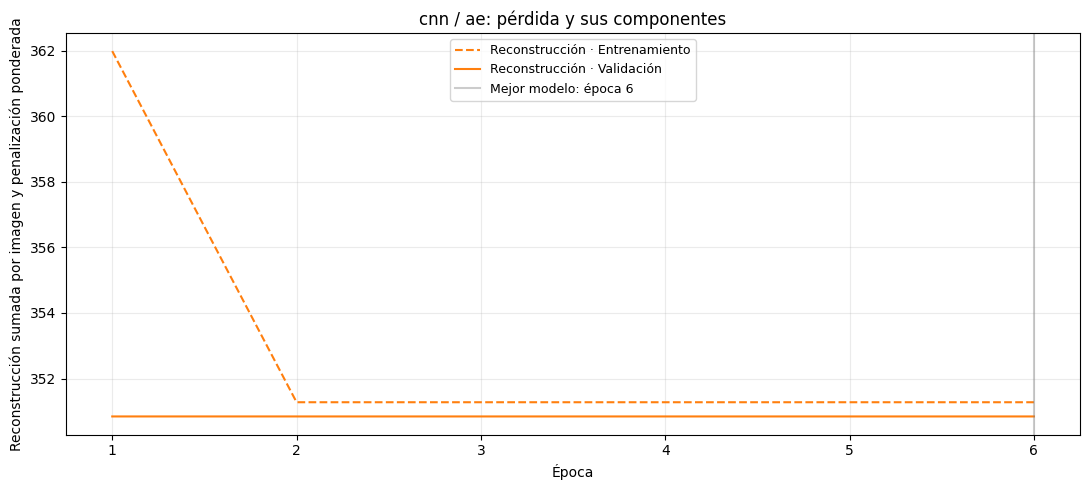

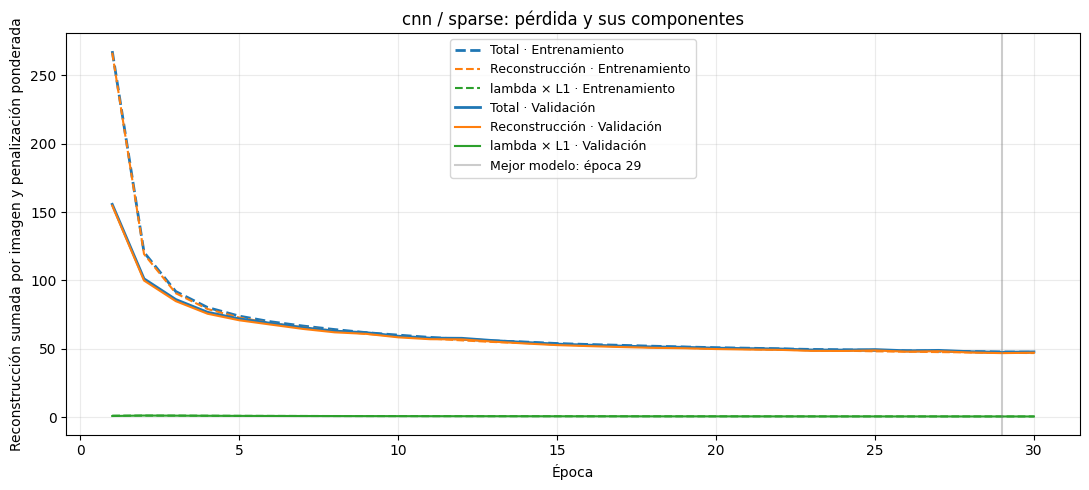

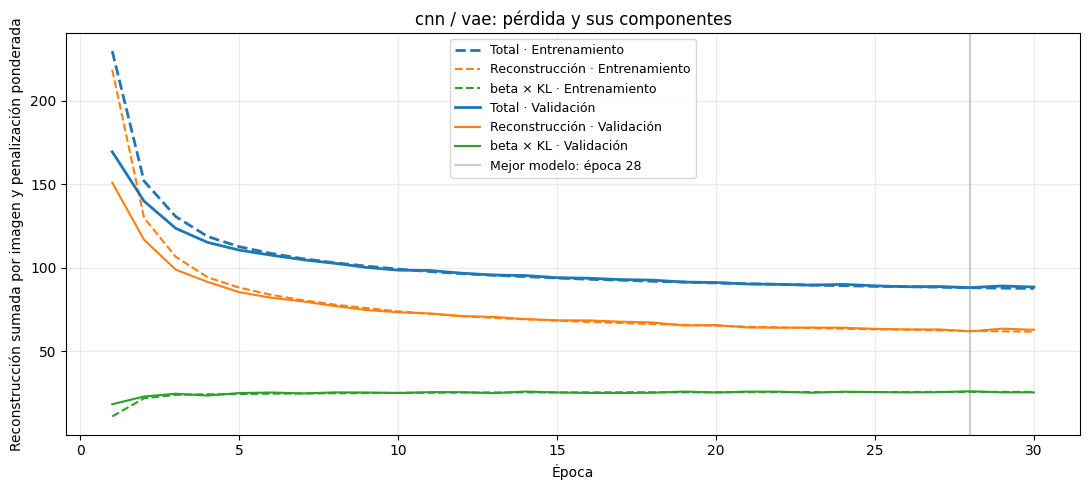

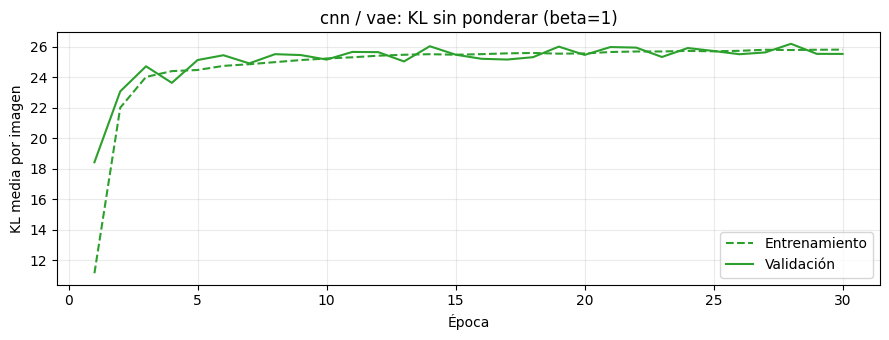

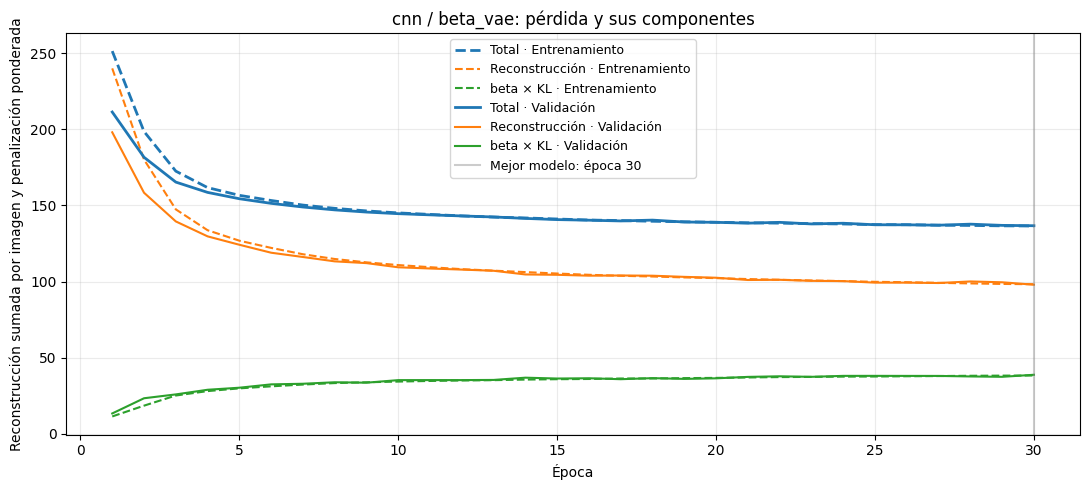

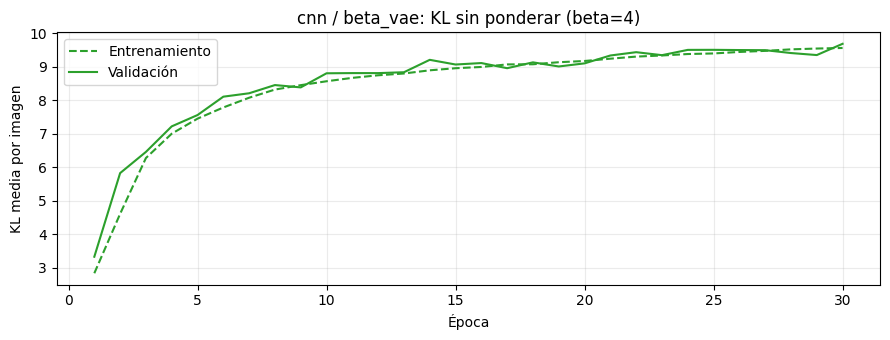

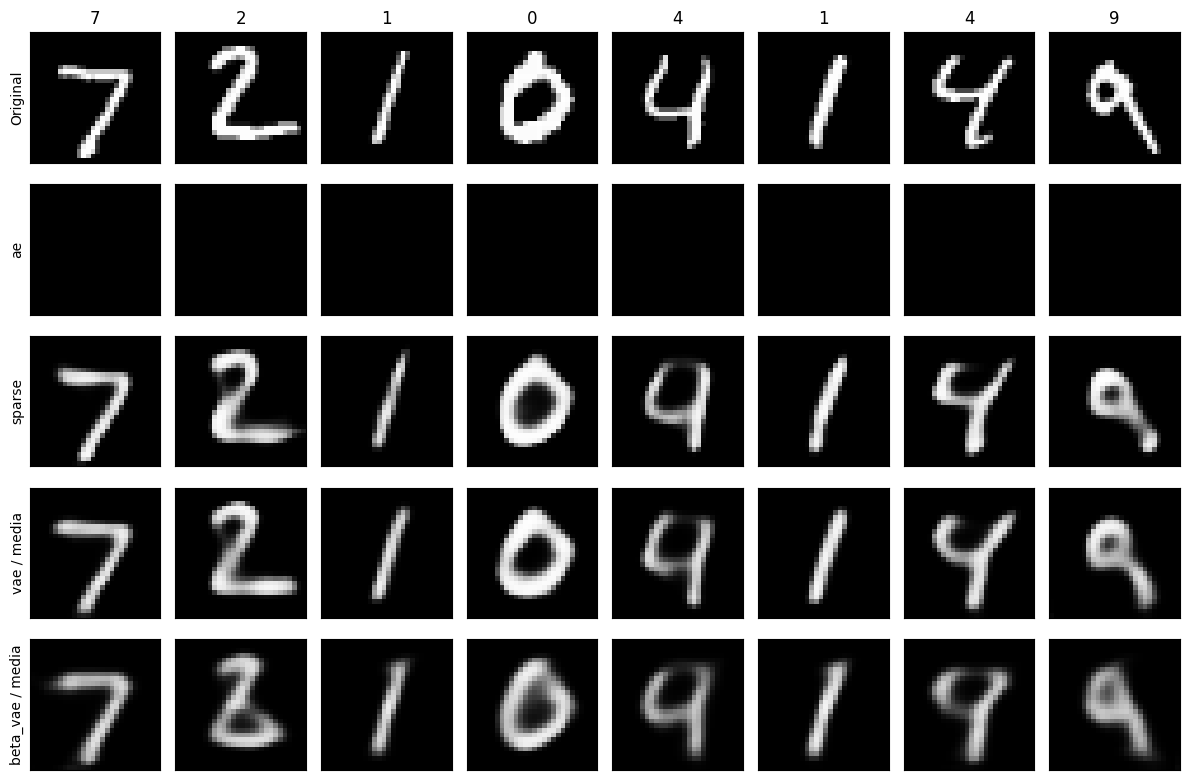

ae         MSE=0.45583  SSE/imagen=357.373  L1=0.0000  KL=0.000  total=357.373
sparse     MSE=0.05844  SSE/imagen=45.814  L1=0.6086  KL=0.000  total=46.423
vae        MSE=0.07725  SSE/imagen=60.564  L1=0.0000  KL=26.229  total=86.792
beta_vae   MSE=0.12320  SSE/imagen=96.592  L1=0.0000  KL=9.722  total=135.481


In [30]:
plot_histories(records)
plot_reconstructions(models, test_loader)
test_results = evaluate_models(models, test_loader)


## 10. Espacio latente

En VAE se dibujan las medias del posterior. Con más de 2 dimensiones se muestra t-SNE,
ajustada por separado para cada modelo y con una semilla fija. Sus ejes no son las
coordenadas latentes originales ni están alineados entre modelos. t-SNE ayuda a visualizar
vecindades; las distancias entre grupos no representan necesariamente las del espacio original.
Con dimensión 2 el scatter muestra el espacio original directamente.
Los colores indican las etiquetas de MNIST, que no participan en el entrenamiento.


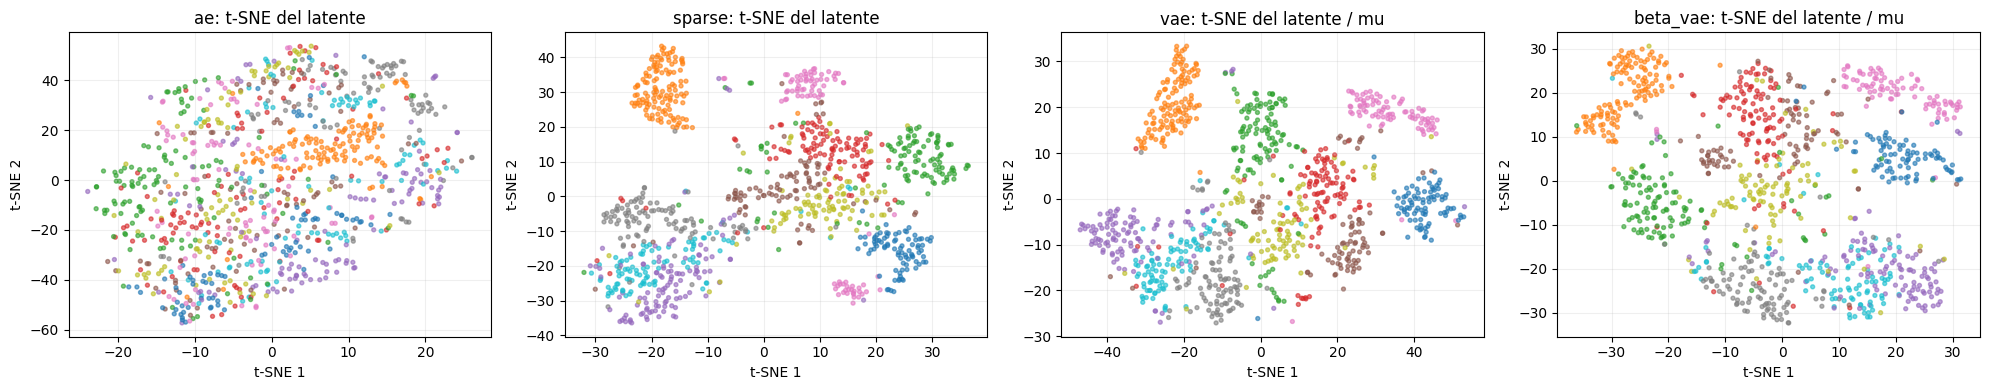

In [31]:
plot_latents(models, test_loader)


## 11. Generación, interpolación y recorridos

VAE y beta-VAE decodifican los mismos puntos muestreados del prior N(0,I).
Una buena reconstrucción no garantiza buena generación desde el prior.

La interpolación une los códigos de dos imágenes y puede variar varias coordenadas.
El recorrido modifica una sola coordenada y mantiene las demás fijas; el rango se toma
como ±2 desvíos observados alrededor del código de una imagen de referencia.
Estos gráficos no prueban por sí solos independencia de factores o disentanglement.


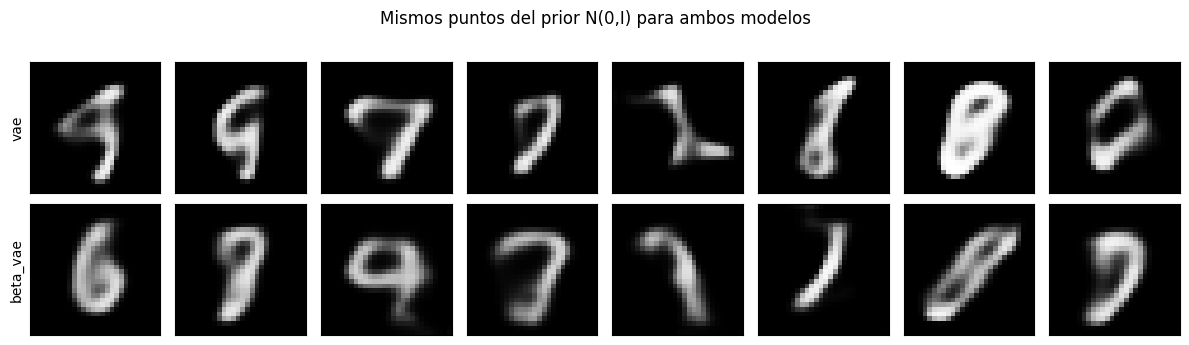

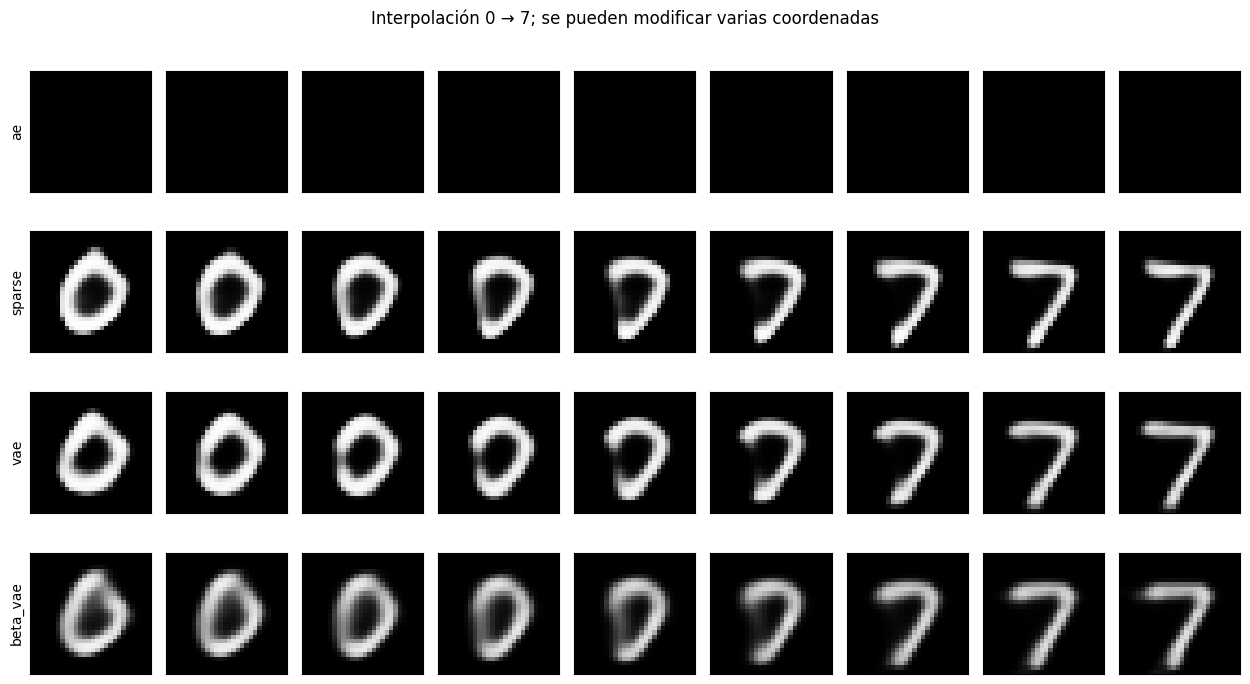

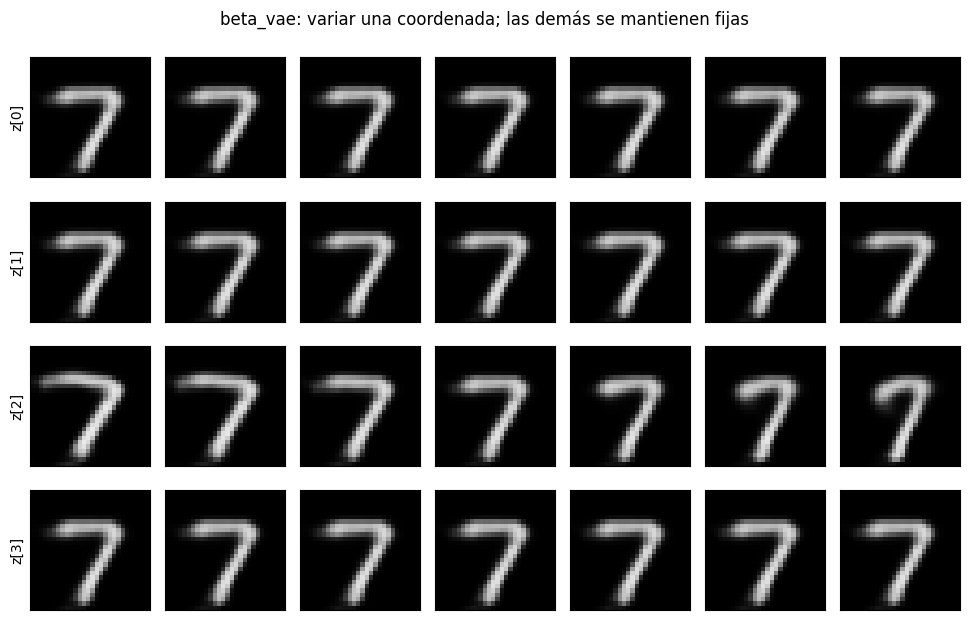

In [32]:
plot_prior_samples(models)
plot_interpolation(models, test_loader, class_a=0, class_b=7)
plot_traversals(models, test_loader, name="beta_vae")
